In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score
import statsmodels.api as sm

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 구조 위험 예측 - 로지스틱

## 1. 데이터 로드 및 Y 라벨 생성

In [14]:
df = pd.read_csv('./data/accidentlevel.csv')

# 파일명 기준 Y 라벨 생성
# _북쪽.png → 0 (직접 수집, 비사고 지역)
# 그 외      → 1 (사고다발지)
df["accident_label"] = df["image"].apply(
    lambda x: 0 if x.endswith("북쪽.png") else 1
)

print(f"전체: {len(df)}행")
print(f"Y=0 (비사고): {(df['accident_label'] == 0).sum()}행")
print(f"Y=1 (사고):   {(df['accident_label'] == 1).sum()}행")
df.head()

전체: 3971행
Y=0 (비사고): 2247행
Y=1 (사고):   1724행


,image,p_wide,p_narrow,p_barrier_yes,p_barrier_no,시설물명,road_width_relative,sidewalk_ratio,parked_density,accident_label
0,AMI몬테소리손바닥어린이집_북쪽.png,0.660075,0.344503,0.382240,0.614802,AMI몬테소리손바닥어린이집,0.400759,0.000000,1,0
1,AP어린이집_북쪽.png,0.940672,0.060079,0.822805,0.178012,AP어린이집,0.428197,0.000000,2,0
2,EPS어린이집_북쪽.png,0.004515,0.995615,0.005522,0.994376,EPS어린이집,0.000000,0.000000,0,0
3,GC차일드케어어린이집_북쪽.png,0.766128,0.228500,0.616568,0.387656,GC차일드케어어린이집,0.402940,0.042165,0,0
4,LIG넥스원_어린이집_북쪽.png,0.797194,0.204120,0.853232,0.151019,LIG넥스원_어린이집,0.345928,0.000000,0,0


## 2. 입력 변수 정의

In [15]:
FEATURES = [
    "p_wide",               # 넓은 도로 확률 (Classification)
    "p_barrier_yes",        # 차단시설 있음 확률 (Classification)
    "parked_density",       # 주정차 밀도 (Object Detection)
    "sidewalk_ratio",       # 보도 비율 (Object Detection)
    "road_width_relative",  # 차도 비율 (Object Detection)
]

X = df[FEATURES]
y = df["accident_label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3971, 5)
y shape: (3971,)


## 3. 로지스틱 회귀 학습 (sklearn)

In [16]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(max_iter=1000))
])

model.fit(X, y)

# 계수 및 오즈비 확인
coef = model.named_steps["logit"].coef_[0]
intercept = model.named_steps["logit"].intercept_[0]

results = pd.DataFrame({
    "variable": FEATURES,
    "coefficient": coef,
    "odds_ratio": np.exp(coef)
})

print(f"Intercept: {intercept:.4f}\n")
print(results.to_string(index=False))

Intercept: -0.3025

           variable  coefficient  odds_ratio
             p_wide     1.236999    3.445260
      p_barrier_yes    -0.804222    0.447436
     parked_density     0.109352    1.115555
     sidewalk_ratio    -0.137334    0.871679
road_width_relative     0.246574    1.279634


## 4. 상세 통계 (statsmodels)

In [17]:
X_sm = sm.add_constant(X)
sm_model = sm.Logit(y, X_sm).fit()
print(sm_model.summary())

print("\nOdds Ratios:")
print(np.exp(sm_model.params))

Optimization terminated successfully.
         Current function value: 0.611239
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:         accident_label   No. Observations:                 3971
Model:                          Logit   Df Residuals:                     3965
Method:                           MLE   Df Model:                            5
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                  0.1070
Time:                        10:49:09   Log-Likelihood:                -2427.2
converged:                       True   LL-Null:                       -2717.9
Covariance Type:            nonrobust   LLR p-value:                2.079e-123
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.6764      0.110    -15.286      0.000      -1.891      -1.461
p_

## 5. 모델 성능 및 Structure Risk 출력

In [18]:
y_pred = model.predict(X)
y_prob = model.predict_proba(X)[:, 1]  # Structure Risk = P(Y=1)

print(f"Accuracy: {accuracy_score(y, y_pred):.4f}")
print(f"ROC-AUC:  {roc_auc_score(y, y_prob):.4f}")

# Structure Risk를 df에 추가
df["structure_risk"] = y_prob
df[["image", "accident_label", "structure_risk"]].head(10)

Accuracy: 0.6656
ROC-AUC:  0.7143


,image,accident_label,structure_risk
0,AMI몬테소리손바닥어린이집_북쪽.png,0,0.602361
1,AP어린이집_북쪽.png,0,0.597917
2,EPS어린이집_북쪽.png,0,0.158024
3,GC차일드케어어린이집_북쪽.png,0,0.500284
4,LIG넥스원_어린이집_북쪽.png,0,0.363006
5,가곡초등학교(병설)_북쪽.png,0,0.279142
6,가남초등학교_북쪽.png,0,0.172923
7,가납초등학교_북쪽.png,0,0.263727
8,가능초등학교_북쪽.png,0,0.333280
9,가람어린이집(해담은어린이집)_북쪽.png,0,0.451083


## 6. seongnam_scaled_with_info.csv에 structure_risk 컬럼 추가 → seongnam_final.csv 저장

In [19]:
# 시설물명별 structure_risk 평균 (이미지가 여러 장인 경우 대비)
risk_per_facility = (
    df.groupby("시설물명")["structure_risk"]
    .mean()
    .reset_index()
    .rename(columns={"structure_risk": "structure_risk"})
)

# seongnam_scaled_with_info.csv 로드
seongnam = pd.read_csv("./data/seongnam_scaled_with_info.csv", encoding="utf-8-sig")
print(f"seongnam 원본: {seongnam.shape}")
print(seongnam.columns.tolist())

# 시설물명 기준으로 structure_risk 병합
seongnam_final = seongnam.merge(risk_per_facility, on="시설물명", how="left")

matched = seongnam_final["structure_risk"].notna().sum()
print(f"\n매칭된 행: {matched} / {len(seongnam_final)}")
print(f"미매칭 행: {seongnam_final['structure_risk'].isna().sum()}")

# 미매칭 확인
unmatched = seongnam_final[seongnam_final["structure_risk"].isna()]["시설물명"].tolist()
if unmatched:
    print(f"\n미매칭 시설물명: {unmatched}")

seongnam_final.head()

seongnam 원본: (142, 14)
['시설물명', '위도', '경도', '도로안전표지', '도로적색표면', '무단횡단방지펜스', '무인교통단속카메라', '보호구역표지판', '생활안전CCTV', '신호등', '옐로카펫', '횡단보도', '어린이 비율(%)', '발생건수']

매칭된 행: 110 / 142
미매칭 행: 32

미매칭 시설물명: ['도촌초등학교', '돌마초등학교', '분당초등학교', '하탑초등학교', '산운초등학교', '성남화랑초등학교', '대원초등학교', '성남제일초등학교', '희망대초등학교', '성남신흥초등학교', '단대초등학교', '복정초등학교', '성남양지초등학교', '위례고운초등학교', '위례한빛초등학교', '위례중앙초등학교', '성남신기초등학교', '이매초등학교', '왕남초등학교', '불곡초등학교', '성남매송초등학교', '중탑초등학교', '고등나래 유치원', '선경유치원', '안촌 유치원', '세화유치원', '꿈터 유치원', '성모 유치원', '아이세상 어린이집', '판교어린이집', '서울국제학교', '케이디엘피어학원']


,시설물명,위도,경도,도로안전표지,도로적색표면,무단횡단방지펜스,무인교통단속카메라,보호구역표지판,생활안전CCTV,신호등,옐로카펫,횡단보도,어린이 비율(%),발생건수,structure_risk
0,중원초등학교,37.437855,127.167857,-1.481298,-0.772935,-0.490819,-1.744931,0.296887,0.241975,-1.552093,0.226073,-1.542884,-1.093852,0,0.220895
1,하원초등학교,37.446255,127.170236,0.969316,-0.433131,0.414328,0.228100,0.296887,0.052158,1.402293,1.210696,0.946770,-0.006369,0,0.408836
2,중부초등학교,37.451546,127.164951,-0.664427,1.605695,0.816615,0.228100,1.164436,0.903731,-0.370339,0.226073,-0.712999,-1.220495,0,0.288019
3,상대원초등학교,37.442382,127.181591,-0.664427,-0.263229,1.319475,-0.500087,0.824886,-1.725175,-0.665777,0.226073,-0.712999,-1.093852,0,0.270135
4,도촌초등학교,37.414730,127.158024,0.560880,-0.093327,0.917187,-0.500087,-0.324357,-1.462103,-0.074900,0.226073,0.531827,0.463700,0,NaN


=== structure_risk 기술통계 ===
  count : 110
  mean  : 0.3751
  std   : 0.1378
  min   : 0.1132
  25%   : 0.2659
  50%   : 0.3673
  75%   : 0.4447
  max   : 0.7805

  왜도 (skewness)  : 0.6182
  첨도 (kurtosis)  : 0.2513
  → 오른쪽 꼬리 (양의 왜도)

  Shapiro-Wilk — W=0.9707, p=0.0159
  → 정규성: ⚠️ 불만족 (p ≤ 0.05)


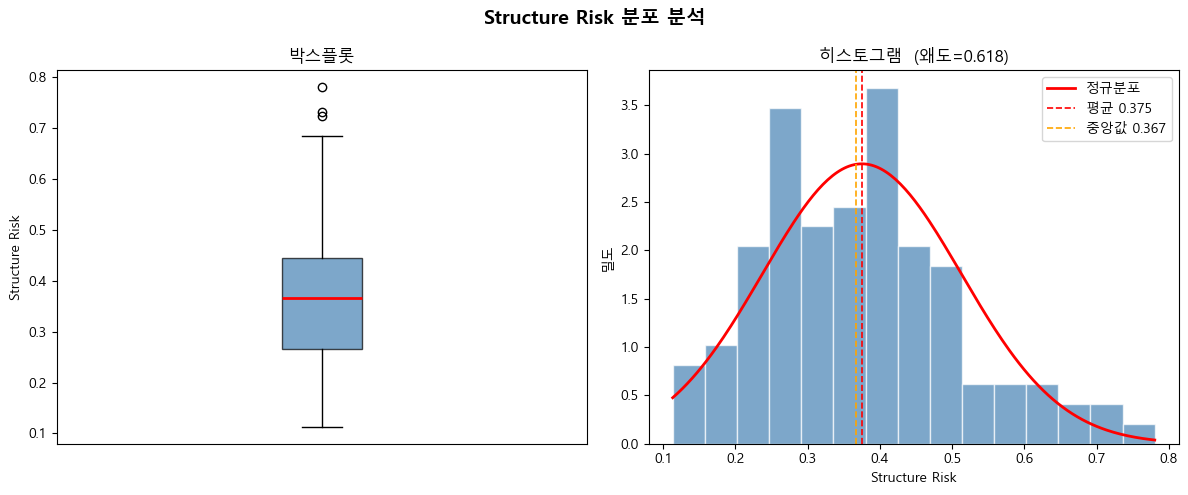

In [20]:
from scipy import stats

risk = seongnam_final["structure_risk"].dropna()

# 기술통계 + 치우침
print("=== structure_risk 기술통계 ===")
print(f"  count : {risk.count()}")
print(f"  mean  : {risk.mean():.4f}")
print(f"  std   : {risk.std():.4f}")
print(f"  min   : {risk.min():.4f}")
print(f"  25%   : {risk.quantile(0.25):.4f}")
print(f"  50%   : {risk.quantile(0.50):.4f}")
print(f"  75%   : {risk.quantile(0.75):.4f}")
print(f"  max   : {risk.max():.4f}")
print(f"\n  왜도 (skewness)  : {risk.skew():.4f}")
print(f"  첨도 (kurtosis)  : {risk.kurt():.4f}")
print(f"  → {'오른쪽 꼬리 (양의 왜도)' if risk.skew() > 0 else '왼쪽 꼬리 (음의 왜도)' if risk.skew() < 0 else '대칭'}")

# Shapiro-Wilk 정규성 검정
stat, p = stats.shapiro(risk)
print(f"\n  Shapiro-Wilk — W={stat:.4f}, p={p:.4f}")
print(f"  → 정규성: {'✅ 만족 (p > 0.05)' if p > 0.05 else '⚠️ 불만족 (p ≤ 0.05)'}")

# 박스플롯
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Structure Risk 분포 분석", fontsize=14, fontweight="bold")

# (1) 박스플롯
axes[0].boxplot(risk, vert=True, patch_artist=True,
                boxprops=dict(facecolor="steelblue", alpha=0.7),
                medianprops=dict(color="red", linewidth=2))
axes[0].set_ylabel("Structure Risk")
axes[0].set_title("박스플롯")
axes[0].set_xticks([])

# (2) 히스토그램 + KDE
axes[1].hist(risk, bins=15, color="steelblue", edgecolor="white", density=True, alpha=0.7)
x_range = np.linspace(risk.min(), risk.max(), 200)
axes[1].plot(x_range, stats.norm.pdf(x_range, risk.mean(), risk.std()),
             "r-", linewidth=2, label="정규분포")
axes[1].axvline(risk.mean(),   color="red",    linestyle="--", linewidth=1.2, label=f"평균 {risk.mean():.3f}")
axes[1].axvline(risk.median(), color="orange", linestyle="--", linewidth=1.2, label=f"중앙값 {risk.median():.3f}")
axes[1].set_xlabel("Structure Risk")
axes[1].set_ylabel("밀도")
axes[1].set_title(f"히스토그램  (왜도={risk.skew():.3f})")
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler_risk = StandardScaler()
seongnam_final["structure_risk"] = scaler_risk.fit_transform(
    seongnam_final[["structure_risk"]]
)

print(f"StandardScaling 완료")
print(f"  mean : {seongnam_final['structure_risk'].mean():.4f}")
print(f"  std  : {seongnam_final['structure_risk'].std():.4f}")

StandardScaling 완료
  mean : 0.0000
  std  : 1.0046


In [22]:
seongnam_train = seongnam_final[seongnam_final["structure_risk"].notna()]
seongnam_test  = seongnam_final[seongnam_final["structure_risk"].isna()]

seongnam_train.to_csv("./data/seongnam_train.csv", index=False, encoding="utf-8-sig")
seongnam_test.to_csv("./data/seongnam_test.csv",   index=False, encoding="utf-8-sig")

print(f"seongnam_train.csv 저장 완료: {len(seongnam_train)}행")
print(f"seongnam_test.csv  저장 완료: {len(seongnam_test)}행")

seongnam_train.csv 저장 완료: 110행
seongnam_test.csv  저장 완료: 32행
